## 1) Setup


In [ ]:
!pip -q install pyspark findspark scikit-learn matplotlib

In [ ]:
import os, glob, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, to_timestamp, hour, dayofweek, month
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, BooleanType, DoubleType

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
BASE_ROOT = "/content/drive/MyDrive/Crimes_-_2001_to_Present.csv"

## 2) Spark session and tuning


In [ ]:
spark = (
    SparkSession.builder
    .appName("Crime_BigData_Project_Medallion")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.files.maxPartitionBytes", str(64 * 1024 * 1024))
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark Version:", spark.version)
print("Default Parallelism:", spark.sparkContext.defaultParallelism)
print("Shuffle Partitions:", spark.conf.get("spark.sql.shuffle.partitions"))


Spark Version: 4.0.2
Default Parallelism: 2
Shuffle Partitions: 200


## 3) Paths and helpers


In [ ]:
import os, glob, shutil, time

DATA_PATH = "/content/drive/MyDrive/Crimes_-_2001_to_Present.csv"

BASE_ROOT = os.path.dirname(DATA_PATH)

if BASE_ROOT.lower().endswith(".csv"):
    BASE_ROOT = os.path.dirname(BASE_ROOT)

print("DATA_PATH:", DATA_PATH)
print("BASE_ROOT:", BASE_ROOT)

MEDALLION_BASE = os.path.join(BASE_ROOT, "7006SCN_medallion")
BRONZE_DIR = os.path.join(MEDALLION_BASE, "bronze")
SILVER_DIR = os.path.join(MEDALLION_BASE, "silver")
GOLD_DIR = os.path.join(MEDALLION_BASE, "gold")
TABLEAU_DIR = os.path.join(BASE_ROOT, "7006SCN_tableau_exports")

for p in [BRONZE_DIR, SILVER_DIR, GOLD_DIR, TABLEAU_DIR]:
    os.makedirs(p, exist_ok=True)

BRONZE_PARQUET = os.path.join(BRONZE_DIR, "crimes_raw_parquet")
SILVER_PARQUET = os.path.join(SILVER_DIR, "crimes_clean_parquet")
GOLD_ML_PARQUET = os.path.join(GOLD_DIR, "ml_ready_parquet")

print("MEDALLION_BASE:", MEDALLION_BASE)
print("TABLEAU_DIR:", TABLEAU_DIR)

DATA_PATH: /content/drive/MyDrive/Crimes_-_2001_to_Present.csv
BASE_ROOT: /content/drive/MyDrive
MEDALLION_BASE: /content/drive/MyDrive/7006SCN_medallion
TABLEAU_DIR: /content/drive/MyDrive/7006SCN_tableau_exports


In [ ]:
def time_it(label, fn):
    t0 = time.perf_counter()
    out = fn()
    t1 = time.perf_counter()
    print(f"{label}: {t1 - t0:.2f}s")
    return out

def export_single_csv(spark_df, file_name, out_dir=TABLEAU_DIR):
    tmp_dir = os.path.join(out_dir, f"_{file_name}_tmp")
    final_csv = os.path.join(out_dir, f"{file_name}.csv")
    spark_df.coalesce(1).write.mode("overwrite").option("header", True).csv(tmp_dir)
    part_file = glob.glob(os.path.join(tmp_dir, "part-*.csv"))[0]
    shutil.copy(part_file, final_csv)
    shutil.rmtree(tmp_dir)
    print("Saved:", final_csv)
    return final_csv


## 4) Bronze layer


In [ ]:
schema = StructType([
    StructField("ID", IntegerType(), True),
    StructField("Case Number", StringType(), True),
    StructField("Date", StringType(), True),
    StructField("Block", StringType(), True),
    StructField("IUCR", StringType(), True),
    StructField("Primary Type", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Location Description", StringType(), True),
    StructField("Arrest", BooleanType(), True),
    StructField("Domestic", BooleanType(), True),
    StructField("Beat", IntegerType(), True),
    StructField("District", IntegerType(), True),
    StructField("Ward", IntegerType(), True),
    StructField("Community Area", IntegerType(), True),
    StructField("FBI Code", StringType(), True),
    StructField("X Coordinate", IntegerType(), True),
    StructField("Y Coordinate", IntegerType(), True),
    StructField("Year", IntegerType(), True),
    StructField("Updated On", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("Location", StringType(), True)
])


In [ ]:
raw_rdd = spark.sparkContext.textFile(DATA_PATH, minPartitions=256)
print("RDD partitions:", raw_rdd.getNumPartitions())
print("RDD first line:", raw_rdd.first()[:120])


RDD partitions: 256
RDD first line: ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Communit


In [ ]:
USE_BRONZE_PARQUET_IF_EXISTS = True
WRITE_BRONZE_PARQUET = True

if USE_BRONZE_PARQUET_IF_EXISTS and os.path.exists(BRONZE_PARQUET):
    df_bronze = spark.read.parquet(BRONZE_PARQUET)
else:
    df_bronze = (
        spark.read
        .option("header", True)
        .option("mode", "PERMISSIVE")
        .option("quote", "\"")
        .option("escape", "\"")
        .schema(schema)
        .csv(DATA_PATH)
    )
    if WRITE_BRONZE_PARQUET:
        time_it("Write Bronze Parquet", lambda: df_bronze.write.mode("overwrite").parquet(BRONZE_PARQUET))

df_bronze.printSchema()
df_bronze.show(5)

if os.path.exists(DATA_PATH):
    size_gb = os.path.getsize(DATA_PATH) / (1024**3)
    print("CSV size (GB):", round(size_gb, 2))


Write Bronze Parquet: 101.39s
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)

+--------+-----------+--------------------+--------------------+--

In [ ]:
dq_year = df_bronze.groupBy("Year").agg(
    count("*").alias("rows_total"),
    count(when(col("Ward").isNull(), 1)).alias("ward_nulls"),
    count(when(col("Community Area").isNull(), 1)).alias("community_nulls"),
    count(when(col("Latitude").isNull(), 1)).alias("lat_nulls"),
    count(when(col("Longitude").isNull(), 1)).alias("lon_nulls"),
    count(when(col("Location Description").isNull(), 1)).alias("locationdesc_nulls"),
)

dq_year = dq_year.withColumn("ward_null_pct", col("ward_nulls") / col("rows_total")) \
                 .withColumn("community_null_pct", col("community_nulls") / col("rows_total")) \
                 .withColumn("lat_null_pct", col("lat_nulls") / col("rows_total")) \
                 .withColumn("lon_null_pct", col("lon_nulls") / col("rows_total"))

dq_year.orderBy("Year").show(8)


+----+----------+----------+---------------+---------+---------+------------------+--------------------+--------------------+--------------------+--------------------+
|Year|rows_total|ward_nulls|community_nulls|lat_nulls|lon_nulls|locationdesc_nulls|       ward_null_pct|  community_null_pct|        lat_null_pct|        lon_null_pct|
+----+----------+----------+---------------+---------+---------+------------------+--------------------+--------------------+--------------------+--------------------+
|2001|    485958|    481572|         479593|     3079|     3079|                 5|  0.9909745286629709|  0.9869021602689945|0.006335938496742517|0.006335938496742517|
|2002|    486831|    133085|         132612|    15301|    15301|                 6| 0.27337001957558166|  0.2723984298452646| 0.03142979802025754| 0.03142979802025754|
|2003|    475999|        20|             48|     3957|     3957|                 5|4.201689499347688E-5|1.008405479843445...|  0.0083130426744594|  0.0083130426

## 5) Silver layer


In [ ]:
df_silver = df_bronze.select(
    col("Date"),
    col("Primary Type").alias("CrimeType"),
    col("Location Description").alias("LocationDesc"),
    col("Arrest"),
    col("Domestic"),
    col("District"),
    col("Ward"),
    col("Community Area").alias("Community"),
    col("Year"),
    col("Latitude"),
    col("Longitude")
)

df_silver = df_silver.fillna({"CrimeType": "Unknown", "LocationDesc": "Unknown"})

df_silver = (
    df_silver
    .withColumn("district_missing", when(col("District").isNull(), 1).otherwise(0))
    .withColumn("ward_missing", when(col("Ward").isNull(), 1).otherwise(0))
    .withColumn("community_missing", when(col("Community").isNull(), 1).otherwise(0))
    .withColumn("lat_missing", when(col("Latitude").isNull(), 1).otherwise(0))
    .withColumn("lon_missing", when(col("Longitude").isNull(), 1).otherwise(0))
)

df_silver = df_silver.withColumn("timestamp", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))
df_silver = df_silver.withColumn(
    "timestamp",
    when(col("timestamp").isNull(), to_timestamp(col("Date"), "M/d/yyyy H:mm")).otherwise(col("timestamp"))
)

df_silver = df_silver.dropna(subset=["timestamp", "Year"])

median_ward = df_silver.approxQuantile("Ward", [0.5], 0.01)[0] if df_silver.filter(col("Ward").isNotNull()).limit(1).count() == 1 else 0
df_silver = df_silver.fillna({"Ward": int(median_ward)})

df_silver = (
    df_silver
    .withColumn("hour", hour("timestamp"))
    .withColumn("day", dayofweek("timestamp"))
    .withColumn("month", month("timestamp"))
    .withColumn("is_weekend", when(col("day").isin([1, 7]), 1).otherwise(0))
    .withColumn("is_night", when((col("hour") <= 5) | (col("hour") >= 22), 1).otherwise(0))
)

df_silver = df_silver.withColumn("label", when(col("Arrest") == True, 1).otherwise(0))
df_silver = df_silver.withColumn("domestic_int", when(col("Domestic") == True, 1).otherwise(0))

df_silver.show(5)


+--------------------+--------------------+--------------------+------+--------+--------+----+---------+----+------------+-------------+----------------+------------+-----------------+-----------+-----------+-------------------+----+---+-----+----------+--------+-----+------------+
|                Date|           CrimeType|        LocationDesc|Arrest|Domestic|District|Ward|Community|Year|    Latitude|    Longitude|district_missing|ward_missing|community_missing|lat_missing|lon_missing|          timestamp|hour|day|month|is_weekend|is_night|label|domestic_int|
+--------------------+--------------------+--------------------+------+--------+--------+----+---------+----+------------+-------------+----------------+------------+-----------------+-----------+-----------+-------------------+----+---+-----+----------+--------+-----+------------+
|07/29/2022 03:39:...|OFFENSE INVOLVING...|           RESIDENCE|  true|   false|      10|  25|       30|2022|        NULL|         NULL|               

In [ ]:
WRITE_SILVER_PARQUET = True
if WRITE_SILVER_PARQUET:
    time_it("Write Silver Parquet", lambda:
            df_silver.repartition("Year").write.mode("overwrite").partitionBy("Year").parquet(SILVER_PARQUET))


Write Silver Parquet: 115.04s


## 6) Gold layer


In [ ]:
df_gold_ml = df_silver.dropna(subset=["District", "Ward", "Community", "Latitude", "Longitude", "hour", "day", "month"])

df_gold_ml = df_gold_ml.select(
    "CrimeType", "LocationDesc",
    "District", "Ward", "Community",
    "Latitude", "Longitude",
    "hour", "day", "month",
    "is_weekend", "is_night",
    "domestic_int",
    "district_missing", "ward_missing", "community_missing", "lat_missing", "lon_missing",
    "Year",
    "label"
)

WRITE_GOLD_ML_PARQUET = True
if WRITE_GOLD_ML_PARQUET:
    time_it("Write Gold ML Parquet", lambda: df_gold_ml.write.mode("overwrite").parquet(GOLD_ML_PARQUET))

df_gold_ml.show(5)
df_gold_ml.groupBy("label").count().show()


Write Gold ML Parquet: 145.49s
+---------------+--------------------+--------+----+---------+------------+-------------+----+---+-----+----------+--------+------------+----------------+------------+-----------------+-----------+-----------+----+-----+
|      CrimeType|        LocationDesc|District|Ward|Community|    Latitude|    Longitude|hour|day|month|is_weekend|is_night|domestic_int|district_missing|ward_missing|community_missing|lat_missing|lon_missing|Year|label|
+---------------+--------------------+--------+----+---------+------------+-------------+----+---+-----+----------+--------+------------+----------------+------------+-----------------+-----------+-----------+----+-----+
|        ROBBERY|              STREET|      14|   1|       24|41.908417822| -87.67740693|   9|  2|    8|         0|       0|           0|               0|           0|                0|          0|          0|2020|    1|
|CRIMINAL DAMAGE|PARKING LOT / GAR...|       1|  42|       32|41.886018055|-87.633937

In [ ]:
biz_table = df_silver.groupBy("Year", "month", "District", "CrimeType").agg(
    F.count("*").alias("Total_Crimes"),
    F.avg("label").alias("Arrest_Rate"),
    F.avg(col("domestic_int")).alias("Domestic_Rate")
)

biz_table.show(5)


+----+-----+--------+--------------------+------------+-------------------+--------------------+
|Year|month|District|           CrimeType|Total_Crimes|        Arrest_Rate|       Domestic_Rate|
+----+-----+--------+--------------------+------------+-------------------+--------------------+
|2023|    9|      24|PUBLIC PEACE VIOL...|           1|                1.0|                 0.0|
|2021|    9|      18|             BATTERY|         142|0.13380281690140844| 0.28169014084507044|
|2023|    2|       8|            BURGLARY|          28|0.03571428571428571| 0.07142857142857142|
|2014|    5|       1|               THEFT|         484|0.18801652892561985|0.010330578512396695|
|2023|    5|      19|             BATTERY|         150|0.10666666666666667|                0.32|
+----+-----+--------+--------------------+------------+-------------------+--------------------+
only showing top 5 rows


## 7) ML training and evaluation


In [ ]:
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

ML_START_YEAR = 2020
ML_END_YEAR = 2024

ml_data = df_gold_ml.filter((col("Year") >= ML_START_YEAR) & (col("Year") <= ML_END_YEAR))
train = ml_data.filter(col("Year") < 2023).persist(StorageLevel.DISK_ONLY)
test  = ml_data.filter(col("Year") >= 2023).persist(StorageLevel.DISK_ONLY)

train.foreachPartition(lambda _: None)
test.foreachPartition(lambda _: None)

print("Train count:", time_it("train.count", lambda: train.count()))
print("Test count:", time_it("test.count", lambda: test.count()))


train.count: 0.62s
Train count: 645640
test.count: 0.52s
Test count: 518782


In [ ]:
crime_index = StringIndexer(inputCol="CrimeType", outputCol="crime_idx", handleInvalid="keep")
loc_index   = StringIndexer(inputCol="LocationDesc", outputCol="loc_idx", handleInvalid="keep")

encoder = OneHotEncoder(
    inputCols=["crime_idx", "loc_idx"],
    outputCols=["crime_ohe", "loc_ohe"]
)

feature_cols = [
    "crime_ohe", "loc_ohe",
    "District", "Ward", "Community",
    "Latitude", "Longitude",
    "hour", "day", "month",
    "is_weekend", "is_night",
    "domestic_int",
    "district_missing", "ward_missing", "community_missing", "lat_missing", "lon_missing"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

feature_pipe = Pipeline(stages=[crime_index, loc_index, encoder, assembler])
feature_model = time_it("Fit feature pipeline", lambda: feature_pipe.fit(train))

train_feat = feature_model.transform(train).select("features", "label").persist(StorageLevel.DISK_ONLY)
test_feat  = feature_model.transform(test).select("features", "label").persist(StorageLevel.DISK_ONLY)

train_feat.foreachPartition(lambda _: None)
test_feat.foreachPartition(lambda _: None)


Fit feature pipeline: 2.46s


In [ ]:
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=20, regParam=0.01)

rf = RandomForestClassifier(
    labelCol="label", featuresCol="features",
    numTrees=50, maxDepth=10, maxBins=64,
    featureSubsetStrategy="sqrt", subsamplingRate=0.7, seed=42
)

gbt = GBTClassifier(
    labelCol="label", featuresCol="features",
    maxIter=50, maxDepth=5, maxBins=64, stepSize=0.1, seed=42
)

model_lr = time_it("Fit LR", lambda: lr.fit(train_feat))
pred_lr = model_lr.transform(test_feat)

model_rf = time_it("Fit RF", lambda: rf.fit(train_feat))
pred_rf = model_rf.transform(test_feat)

model_gbt = time_it("Fit GBT", lambda: gbt.fit(train_feat))
pred_gbt = model_gbt.transform(test_feat)


Fit LR: 20.39s
Fit RF: 203.77s
Fit GBT: 930.87s


In [ ]:
auc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")
acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

def metrics_row(name, pred_df):
    return {
        "Model": name,
        "AUC": float(auc_eval.evaluate(pred_df)),
        "Accuracy": float(acc_eval.evaluate(pred_df)),
        "F1": float(f1_eval.evaluate(pred_df))
    }

metrics = [
    metrics_row("LogisticRegression", pred_lr),
    metrics_row("RandomForest", pred_rf),
    metrics_row("GBT", pred_gbt),
]

tableau_model_metrics = spark.createDataFrame(metrics)
tableau_model_metrics.show(truncate=False)


+------------------+------------------+------------------+------------------+
|AUC               |Accuracy          |F1                |Model             |
+------------------+------------------+------------------+------------------+
|0.8328437173536141|0.9024966170761515|0.8854828506487482|LogisticRegression|
|0.8154185330229788|0.8906901164651048|0.8551689970608576|RandomForest      |
|0.8485439987485486|0.9054978777212779|0.8872934639829348|GBT               |
+------------------+------------------+------------------+------------------+



In [ ]:
tune_train = train_feat.sample(withReplacement=False, fraction=0.15, seed=42).persist(StorageLevel.DISK_ONLY)
tune_train.foreachPartition(lambda _: None)

paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [30, 50])
             .addGrid(rf.maxDepth, [7, 10])
             .build())

tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=auc_eval,
    trainRatio=0.8,
    parallelism=2
)

tuned = time_it("Tune RF", lambda: tvs.fit(tune_train))
best_rf = tuned.bestModel
best_pred = best_rf.transform(test_feat)

print("Best RF AUC:", float(auc_eval.evaluate(best_pred)))


Tune RF: 234.83s
Best RF AUC: 0.8144576489404425


## 8) Learning curve


   train_fraction       auc        f1  fit_seconds
0            0.05  0.810311  0.277182        49.27
1            0.10  0.813836  0.279056        62.63
2            0.20  0.811563  0.265016        81.88
3            0.40  0.814436  0.280897       104.89
4            0.60  0.806698  0.284437       155.87
5            0.80  0.823801  0.280079       183.33
6            1.00  0.816826  0.289648       234.39


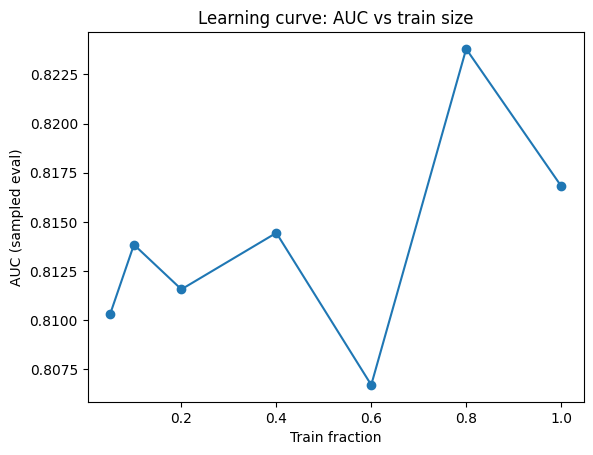

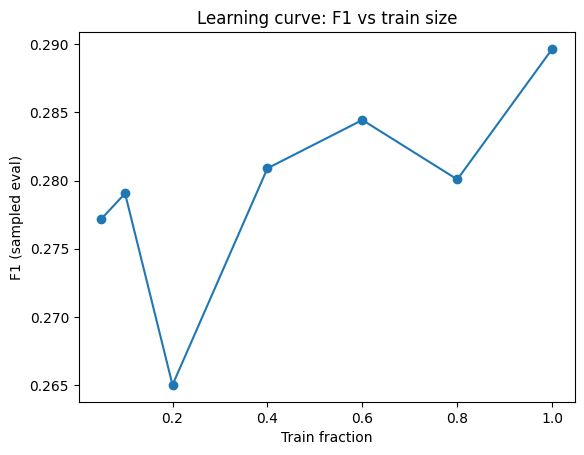

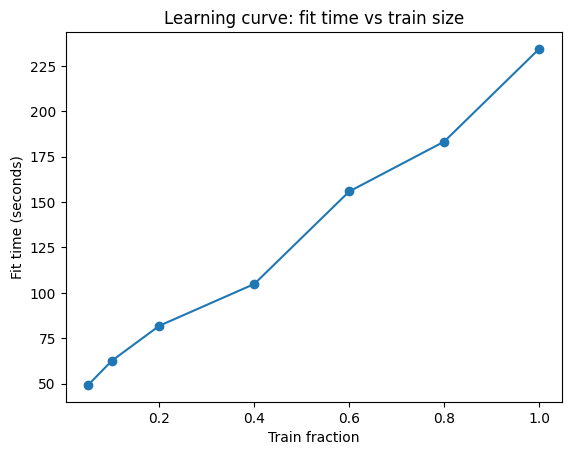

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score
from pyspark.ml.functions import vector_to_array

fractions = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    sub = train_feat.sample(withReplacement=False, fraction=frac, seed=42).persist(StorageLevel.DISK_ONLY)
    sub.foreachPartition(lambda _: None)

    t0 = time.perf_counter()
    m = rf.fit(sub)
    t1 = time.perf_counter()

    p = m.transform(test_feat).select("label", "prediction", vector_to_array(col("probability")).getItem(1).alias("p1")) \
                              .sample(False, 0.25, seed=42).toPandas()

    auc = roc_auc_score(p["label"], p["p1"])
    f1 = f1_score(p["label"], p["prediction"])
    rows.append({"train_fraction": frac, "auc": auc, "f1": f1, "fit_seconds": round(t1 - t0, 2)})

    sub.unpersist(blocking=False)

lc = pd.DataFrame(rows)
print(lc)

plt.figure()
plt.plot(lc["train_fraction"], lc["auc"], marker="o")
plt.xlabel("Train fraction")
plt.ylabel("AUC (sampled eval)")
plt.title("AUC vs train size")
plt.show()

plt.figure()
plt.plot(lc["train_fraction"], lc["f1"], marker="o")
plt.xlabel("Train fraction")
plt.ylabel("F1 (sampled eval)")
plt.title("F1 vs train size")
plt.show()

plt.figure()
plt.plot(lc["train_fraction"], lc["fit_seconds"], marker="o")
plt.xlabel("Train fraction")
plt.ylabel("Fit time (seconds)")
plt.title("fit time vs train size")
plt.show()


## 9) Confusion matrix, ROC curve, Precision-Recall curve


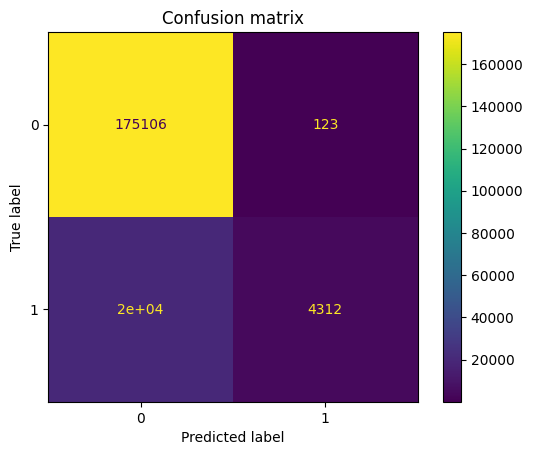

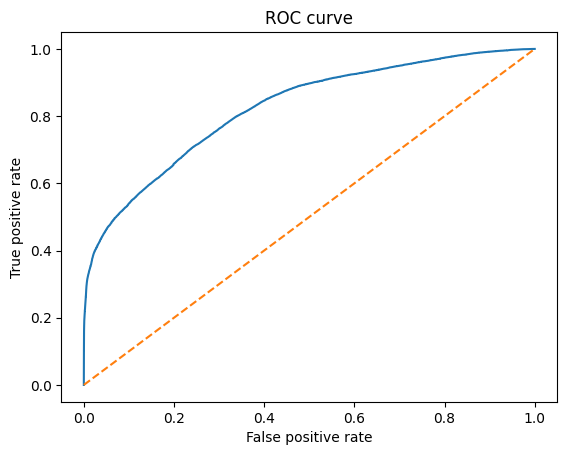

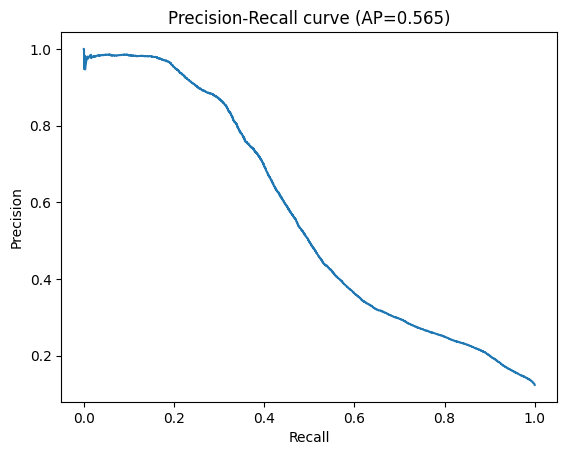

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score

plot_sample_n = 200000

pdf = best_pred.select(
    col("label").cast("int").alias("y"),
    col("prediction").cast("int").alias("yhat"),
    vector_to_array(col("probability")).getItem(1).alias("p1")
).limit(plot_sample_n).toPandas()

cm = confusion_matrix(pdf["y"], pdf["yhat"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix")
plt.show()

fpr, tpr, _ = roc_curve(pdf["y"], pdf["p1"])
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.show()

prec, rec, _ = precision_recall_curve(pdf["y"], pdf["p1"])
ap = average_precision_score(pdf["y"], pdf["p1"])
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP={ap:.3f})")
plt.show()

## 10) Feature importance (Random Forest)


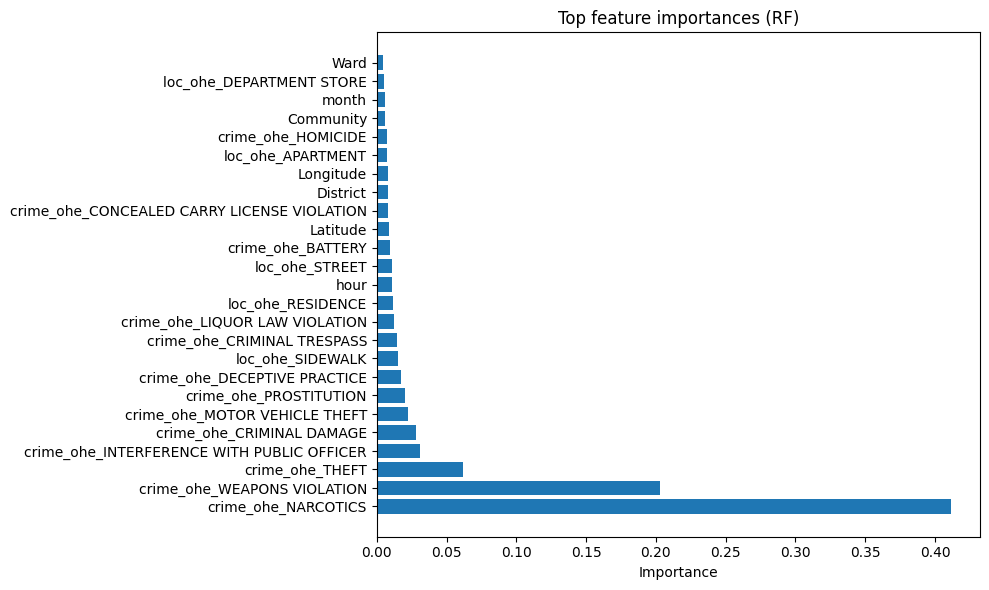

In [ ]:
def get_feature_names_from_vector(df_with_features, features_col="features"):
    meta = df_with_features.schema[features_col].metadata
    if "ml_attr" not in meta:
        return None
    attrs = meta["ml_attr"].get("attrs", {})
    names = []
    for k in ["binary", "numeric", "nominal"]:
        if k in attrs:
            names.extend([a["name"] for a in attrs[k]])
    return names

feat_df_for_meta = feature_model.transform(train).select("features", "label")
feature_names = get_feature_names_from_vector(feat_df_for_meta, "features")

importances = best_rf.featureImportances.toArray()
top_k = 25
idx = np.argsort(importances)[::-1][:top_k]

if feature_names is None or len(feature_names) != len(importances):
    labels = [f"f_{i}" for i in idx]
else:
    labels = [feature_names[i] for i in idx]

vals = importances[idx]

plt.figure(figsize=(10, 6))
plt.barh(range(top_k)[::-1], vals[::-1])
plt.yticks(range(top_k)[::-1], labels[::-1])
plt.xlabel("Importance")
plt.title("Top feature importances (RF)")
plt.tight_layout()
plt.show()


## 11) CPU scalability table


In [ ]:
def time_rf_fit(shuffle_parts):
    spark.conf.set("spark.sql.shuffle.partitions", str(shuffle_parts))
    t0 = time.perf_counter()
    _ = rf.fit(train_feat)
    t1 = time.perf_counter()
    return round(t1 - t0, 2)

scal_rows = []
for sp in [100, 200, 400]:
    scal_rows.append({"Experiment": "RF_fit_on_features", "ShufflePartitions": sp, "RuntimeSeconds": time_rf_fit(sp)})

tableau_scalability = spark.createDataFrame(scal_rows)
tableau_scalability.show()
spark.conf.set("spark.sql.shuffle.partitions", "200")


+------------------+--------------+-----------------+
|        Experiment|RuntimeSeconds|ShufflePartitions|
+------------------+--------------+-----------------+
|RF_fit_on_features|        216.86|              100|
|RF_fit_on_features|         212.8|              200|
|RF_fit_on_features|        210.38|              400|
+------------------+--------------+-----------------+



## 12) Tableau exports


In [ ]:
export_single_csv(dq_year.orderBy("Year"), "dashboard1_data_quality")
export_single_csv(tableau_model_metrics, "dashboard2_model_performance")
export_single_csv(biz_table, "dashboard3_business_insights")
export_single_csv(tableau_scalability, "dashboard4_scalability_runtime")

print("Exports folder:", TABLEAU_DIR)


Saved: /content/drive/MyDrive/7006SCN_tableau_exports/dashboard1_data_quality.csv
Saved: /content/drive/MyDrive/7006SCN_tableau_exports/dashboard2_model_performance.csv
Saved: /content/drive/MyDrive/7006SCN_tableau_exports/dashboard3_business_insights.csv
Saved: /content/drive/MyDrive/7006SCN_tableau_exports/dashboard4_scalability_runtime.csv
Exports folder: /content/drive/MyDrive/7006SCN_tableau_exports


## 13) Cleanup


In [ ]:
try:
    train_feat.unpersist(blocking=False)
    test_feat.unpersist(blocking=False)
    train.unpersist(blocking=False)
    test.unpersist(blocking=False)
except Exception:
    pass

print("Done")


Done
